# Notebook 11 - Unified EDA
**Purpose** Exploratory data analysis on the full cross-jurisdiction enforcement corpus.
Defines penalty severity tiers via k-means and documents label and text distributions
across both corpora.

**Inputs**
- `data/unified_cases.csv` (2,754 rows, 11 fields — output of nb09)

**Outputs**
- `data/unified_cases.csv` (updated: adds `severity_tier` column)
- Elbow plot (inline)

**Key decisions**
- Zero-amount EU penalties excluded from k-means (`penalty_amount > 0` filter);
  some DPA decisions record €0 explicitly rather than leaving fine as null
- Elbow method on log10-transformed penalties selected k=3 for fined cases
- "No Fine" added as a fourth ordinal tier — qualitatively distinct from a low fine;
  log(0) is undefined so these cases cannot participate in k-means
- Final severity tiers: No Fine / Low / Medium / High

**Last run:** 2026-07-21 — 2,754 total (337 US, 2,417 EU), 1,375 fined cases

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

import os
os.makedirs("/Users/nic/Documents/MM2/figures", exist_ok=True)
print("figures directory ready")

figures directory ready


In [2]:
#load our .csv into dataframe, split into separate jurisdictions to verify cases

df = pd.read_csv("/Users/nic/Documents/MM2/data/unified_cases.csv")
us = df[df['jurisdiction'] == 'US']
eu = df[df['jurisdiction'] != 'US']
print(f"Total: {len(df)} | US: {len(us)} | EU: {len(eu)}\n")
print(f"With penalty — US: {us['penalty_amount'].notna().sum()} | EU: {eu['penalty_amount'].notna().sum()}")

Total: 2754 | US: 337 | EU: 2417

With penalty — US: 146 | EU: 1231


In [12]:
# Fixed mid-2026 exchange rates to USD
# Source: approximate market rates July 2026
fx = {
    "USD": 1.000,
    "EUR": 1.080,
    "GBP": 1.270,
    "NOK": 0.090,
    "CHF": 1.110,
    "SEK": 0.094,
    "DKK": 0.145,
    "PLN": 0.250,
    "HUF": 0.0027,
    "RON": 0.220,
    "CZK": 0.044,
    "BGN": 0.550,
    "ISK": 0.0072,# Iceland — 101 cases in corpus
    "HRK": 0.143 
}

df['penalty_usd'] = df.apply(
    lambda row: row['penalty_amount'] * fx.get(str(row['penalty_currency']), float('nan'))
    if pd.notna(row['penalty_amount']) else pd.NA,
    axis=1
)

print("=== Conversion coverage ===")
print(f"penalty_amount non-null: {df['penalty_amount'].notna().sum()}")
print(f"penalty_usd non-null:    {df['penalty_usd'].notna().sum()}")
unmapped = df[df['penalty_amount'].notna() & df['penalty_usd'].isna()]['penalty_currency'].value_counts()
if len(unmapped):
    print(f"\nUnmapped currencies (excluded):\n{unmapped}")

=== Conversion coverage ===
penalty_amount non-null: 1377
penalty_usd non-null:    1377


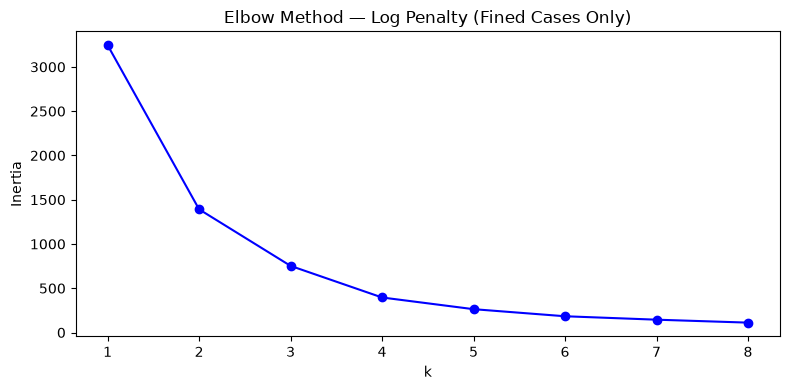

Fined cases: 1375 (US: 146, EU: 1229)


In [13]:
#from US, 0 fine is NaN, this is correct,
#from EU, fine is numerical 0, also fine, may consider unifying with NaN in future.

#fined df removes NaNs and 0s for penalty_amount from working dataset for elbow method.

fined = df[(df['penalty_usd'].notna()) & (df['penalty_usd'] > 0)].copy()
fined['log_penalty'] = np.log10(fined['penalty_usd'].astype(float))
X = fined['log_penalty'].values.reshape(-1, 1)

inertias = []
for k in range(1, 9):
    km = KMeans(n_clusters=k, random_state=777, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 9), inertias, 'bo-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Elbow Method — Log Penalty (Fined Cases Only)')
plt.tight_layout()
plt.savefig("/Users/nic/Documents/MM2/figures/elbow_plot.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Fined cases: {len(fined)} (US: {(fined['jurisdiction']=='US').sum()}, EU: {(fined['jurisdiction']!='US').sum()})")

# Note
3 seems to be the logical choice, with our NaN/0 subset this gives us 4 ordinal categories:
- No fine
- low
- medium
- high

In [14]:
k = 3
km = KMeans(n_clusters=k, random_state=42, n_init=10)
fined['cluster'] = km.fit_predict(X)

centers = km.cluster_centers_.flatten()
sorted_idx = np.argsort(centers)
tier_map = {sorted_idx[i]: ['Low', 'Medium', 'High'][i] for i in range(k)}
fined['severity_tier'] = fined['cluster'].map(tier_map)

print("Cluster centers:")
for i, label in enumerate(['Low', 'Medium', 'High']):
    c = centers[sorted_idx[i]]
    print(f"  {label}: 10^{c:.2f} = ${10**c:,.0f}")

print("\nTier counts:")
print(fined['severity_tier'].value_counts().sort_index())

print("\nTier ranges:")
for tier in ['Low', 'Medium', 'High']:
    s = fined[fined['severity_tier'] == tier]['penalty_usd']
    print(f"  {tier}: ${s.min():,.0f} – ${s.max():,.0f}")

Cluster centers:
  Low: 10^1.53 = $34
  Medium: 10^4.16 = $14,390
  High: 10^6.28 = $1,925,333

Tier counts:
severity_tier
High      404
Low       126
Medium    845
Name: count, dtype: int64

Tier ranges:
  Low: $0 – $657
  Medium: $756 – $165,100
  High: $169,000 – $5,000,000,000


In [15]:
# Merge severity_tier back onto the full dataframe
# Only fined cases got a tier from k-means; no-fine cases get their own tier
df['severity_tier'] = pd.NA
df.loc[fined.index, 'severity_tier'] = fined['severity_tier']
df.loc[df['penalty_amount'].isna() | (df['penalty_amount'] == 0), 'severity_tier'] = 'No Fine'

print("=== Final severity tier distribution ===")
print(df['severity_tier'].value_counts())
print(f"\nTotal accounted for: {df['severity_tier'].notna().sum()} / {len(df)}")

# Save back to unified_cases.csv
df.to_csv("/Users/nic/Documents/MM2/data/unified_cases.csv", index=False)
print("Saved.")

=== Final severity tier distribution ===
severity_tier
No Fine    1379
Medium      845
High        404
Low         126
Name: count, dtype: int64

Total accounted for: 2754 / 2754
Saved.


In [16]:
# US: how many cases per violation label
print("=== US Violation Label Distribution ===")
print(df[df['jurisdiction'] == 'US']['violation_labels_native'].value_counts())

# EU: GDPR articles are semicolon-separated, need to explode them
print("\n=== EU Top GDPR Articles ===")
eu_articles = (df[df['jurisdiction'] != 'US']['violation_labels_native']
               .dropna()
               .str.split(';')
               .explode()
               .str.strip())
print(eu_articles.value_counts().head(15))

=== US Violation Label Distribution ===
violation_labels_native
Section 5 Only                    182
FCRA                               54
COPPA                              47
GLBA                               23
Health Breach Notification          6
FCRA; GLBA                          6
Privacy Shield                      5
Other                               3
Unknown                             3
Privacy Shield; Section 5 Only      2
TSR; GLBA                           2
CAN-SPAM                            1
FCRA; TSR                           1
TSR; FCRA                           1
Other; Section 5 Only               1
Name: count, dtype: int64

=== EU Top GDPR Articles ===
violation_labels_native
Article 5(1)(a) GDPR    438
Article 13 GDPR         307
Article 5(1)(f) GDPR    273
Article 5(1)(c) GDPR    269
Article 6(1) GDPR       261
Article 32 GDPR         256
Article 6 GDPR          237
Article 15 GDPR         224
Article 5(2) GDPR       209
Article 6(1)(f) GDPR    193
Articl

# Taxonomy Mapping
a rudimentary unifying taxonomy for the purpose of training, and to get our ML work up and running, defined as follows: 

**Security** 
- US: GLBA, HBNR
- EU: Articles 25, 32
  
**Consent**
- US: COPPA, Privacy Shield
- EU: Articles 6, 7, 8

**Transparency**
- Section 5 only (deception cases)
- EU: Articles 13, 14

**Other**
- US: FCRA, Other, Section 5 (unfairness)
- EU: Articles 5, 83, everything else

See paper for official definitions of these labels

In [17]:
# Map US violation labels to 4-class shared taxonomy
us_map = {
    "COPPA":                    "Consent",
    "Privacy Shield":           "Consent",
    "GLBA":                     "Security",
    "HBNR":                     "Security",
    "Section 5 Only":           "Transparency",
    "FCRA":                     "Other",
    "Other":                    "Other",
    "Unknown":                  "Other",
}

# Map EU GDPR articles to 4-class shared taxonomy
# Multi-article cases: take the first article listed
eu_map = {
    "Article 5":   "Other",
    "Article 6":   "Consent",
    "Article 7":   "Consent",
    "Article 8":   "Consent",
    "Article 13":  "Transparency",
    "Article 14":  "Transparency",
    "Article 17":  "Consent",
    "Article 25":  "Security",
    "Article 32":  "Security",
    "Article 83":  "Other",
}

def map_coarse(row):
    if row['jurisdiction'] == 'US':
        return us_map.get(row['violation_labels_native'], "Other")
    else:
        if pd.isna(row['violation_labels_native']):
            return pd.NA
        raw = row['violation_labels_native']
        articles = [a.split('(')[0].split(' GDPR')[0].strip()
                    for a in raw.split(';')]
        for priority in ["Article 32", "Article 25",
                         "Article 6", "Article 7", "Article 8", "Article 17",
                         "Article 13", "Article 14"]:
            if priority in articles:
                return eu_map[priority]
        return "Other"

df['coarse_label'] = df.apply(map_coarse, axis=1)

print("=== Coarse label distribution ===")
print(df['coarse_label'].value_counts())
print("\n=== By jurisdiction ===")
print(df.groupby(['jurisdiction', 'coarse_label']).size().unstack(fill_value=0))

=== Coarse label distribution ===
coarse_label
Consent         943
Other           758
Security        587
Transparency    339
Name: count, dtype: int64

=== By jurisdiction ===
coarse_label    Consent  Other  Security  Transparency
jurisdiction                                          
Austria              41     48         5             5
Belgium             129     52        43            16
Bulgaria              8      0         2             0
Croatia              15      4         6             1
Cyprus               11      9         7             0
Czech Republic        4      1         0             0
Denmark              25     22        46             2
Estonia              14     10         2             1
European Union        8      1         1             1
Finland              15     33        37             2
France               13     17        35            11
Germany               7      6         7             2
Greece               29     53        29            

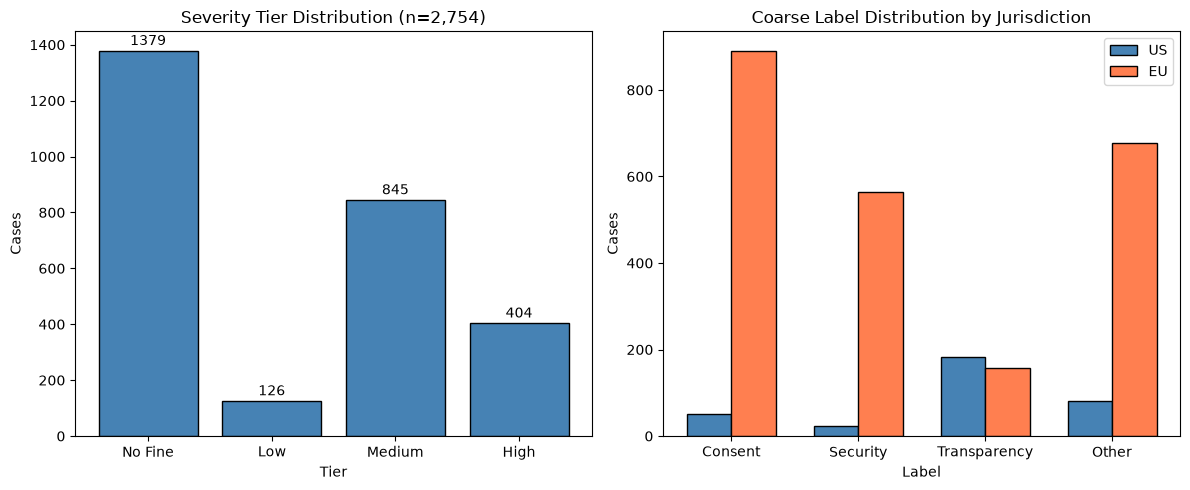

In [18]:
##Visualizations
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: severity tier distribution
tier_order = ['No Fine', 'Low', 'Medium', 'High']
tier_counts = df['severity_tier'].value_counts().reindex(tier_order)
axes[0].bar(tier_order, tier_counts.values, color='steelblue', edgecolor='black')
axes[0].set_title('Severity Tier Distribution (n=2,754)')
axes[0].set_xlabel('Tier')
axes[0].set_ylabel('Cases')
for i, v in enumerate(tier_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=10)

# Right: coarse label by jurisdiction (US vs EU)
us_counts = df[df['jurisdiction']=='US']['coarse_label'].value_counts()
eu_counts = df[df['jurisdiction']!='US']['coarse_label'].value_counts()
labels = ['Consent', 'Security', 'Transparency', 'Other']
x = range(len(labels))
width = 0.35
axes[1].bar([i - width/2 for i in x], [us_counts.get(l, 0) for l in labels],
            width, label='US', color='steelblue', edgecolor='black')
axes[1].bar([i + width/2 for i in x], [eu_counts.get(l, 0) for l in labels],
            width, label='EU', color='coral', edgecolor='black')
axes[1].set_title('Coarse Label Distribution by Jurisdiction')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Cases')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(labels)
axes[1].legend()

plt.tight_layout()
plt.savefig("/Users/nic/Documents/MM2/figures/eda_distributions.png", dpi=150, bbox_inches='tight')
plt.show()